In [2]:
#Importing libraries
import pandas as pd 
import numpy as np 
import os 
import json 
import pickle 
import warnings
from datetime import datetime 

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F

from transformers import DistilBertTokenizer, DistilBertModel

from tqdm import tqdm
warnings.filterwarnings('ignore')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device         : {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

print("Libraries loaded.")
print(f"Run started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

c:\Projects\Cinemate V2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device         : cuda
PyTorch version: 2.7.1+cu118
Libraries loaded.
Run started: 2026-05-31 11:37:03


In [3]:
#Getting the project root path 
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, "data")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
MODELS_DIR = os.path.join(os.path.join(BASE_DIR, "models"))
PLOTS_DIR = os.path.join(PROCESSED_DATA_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Base directory: {BASE_DIR}")

Base directory: c:\Projects\Cinemate V2


In [4]:
#Load processed directories
print("Loading preprocessed file...............")


train = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "train.parquet"))
test = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "test.parquet"))
movies_clean = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "movies_clean.parquet"))
content_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "movie_content.csv"))

with open(os.path.join(PROCESSED_DATA_DIR, "dataset_constants.pkl"), "rb") as f:
    constants = pickle.load(f)

NUM_USERS = constants["NUM_USERS"]
NUM_MOVIES = constants["NUM_MOVIES"]

with open(os.path.join(PROCESSED_DATA_DIR, "user_positive_sets.pkl") , "rb") as f:
    user_positive_sets = pickle.load(f)

with open(os.path.join(PROCESSED_DATA_DIR, "encoders/idx2movie.pkl"), "rb") as f:
    idx2movie = pickle.load(f)

with open(os.path.join(PROCESSED_DATA_DIR, "encoders/idx2user.pkl"), 'rb') as f:
    idx2user = pickle.load(f)

# Load NCF results 
with open(os.path.join(MODELS_DIR,"ncf_results.json"), "r") as f:
    ncf_results_baseline = json.load(f)

print(f"Train ratings: {len(train)}")
print(f"Test ratings : {len(test)}")
print(f"Num Users : {NUM_USERS}")
print(f"Num Movies : {NUM_MOVIES}")


Loading preprocessed file...............
Train ratings: 25868311
Test ratings : 795563
Num Users : 173134
Num Movies : 27766


In [5]:
movies_clean

,movieId,movie_idx,title,genres_clean,genome_tag_string,raw_tag_string,content_string,tmdbId,imdbId
0,1,0,Toy Story (1995),Adventure Animation Children Comedy Fantasy,toys computer animation pixar animation animat...,animation friendship toys disney pixar cgi cla...,Toy Story (1995) | Adventure Animation Childre...,862,114709
1,2,1,Jumanji (1995),Adventure Children Fantasy,adventure children fantasy kids childhood spec...,animals based on a book fantasy magic board ga...,Jumanji (1995) | Adventure Children Fantasy | ...,8844,113497
2,3,2,Grumpier Old Men (1995),Comedy Romance,good sequel sequel sequels comedy original min...,sequel moldy old old age old men wedding old p...,Grumpier Old Men (1995) | Comedy Romance | goo...,15602,113228
3,4,3,Waiting to Exhale (1995),Comedy Drama Romance,women chick flick girlie movie romantic divorc...,characters chick flick girl movie revenge clv ...,Waiting to Exhale (1995) | Comedy Drama Romanc...,31357,114885
4,5,4,Father of the Bride Part II (1995),Comedy,good sequel sequel sequels midlife crisis preg...,family pregnancy wedding 4th wall aging baby d...,Father of the Bride Part II (1995) | Comedy | ...,11862,113041
...,...,...,...,...,...,...,...,...,...
27761,191349,27761,America The Story of Us (2010),Documentary,,,America The Story of Us (2010) | Documentary,105177,1641653
27762,191357,27762,Midnighters (2018),Thriller,,new year's eve rhode island,Midnighters (2018) | Thriller | new year's eve...,460279,5737582
27763,191361,27763,Cheaters (2000),Drama,,,Cheaters (2000) | Drama,15869,218094
27764,191363,27764,Fucking Berlin (2016),Drama Romance,,berlin deutsch german germany female nudity nu...,Fucking Berlin (2016) | Drama Romance | berlin...,376969,4024814


In [4]:
#Precompute content embeddings
EMBED_PATH = os.path.join(PROCESSED_DATA_DIR, "content_embeddings.pt")
if os.path.exists(EMBED_PATH):
    print("Loading precomputed embedding from storage......")
    content_embeddings = torch.load(EMBED_PATH, map_location="cpu")
    print(f"Loaded : {content_embeddings.shape}")      
else: 
    print("Pre computing DistilBERT embeddings..........")
    print("This runs once - saved for all future training runs.")
    print()

    #BERT = a pretrained model that converts text into meaningful vectors
    tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")    #Converts text → tokens (numbers)
    bert_model= DistilBertModel.from_pretrained("distilbert-base-uncased").to(DEVICE)    # convert tokens to embeddings
    bert_model.eval()      #set evaluation mode

    #Built ordered 
    content_lookup= dict(zip(content_df['movie_idx'], content_df['content_string']))
    content_strings = [content_lookup.get(i, "unknown movie") for i in range(NUM_MOVIES)]   #movie_idx → correct text  0->action movies, 1-> Romantic movied
    
    embeddings = []
    BATCH_SIZE = 64

    with torch.no_grad():
        for i in tqdm(range(0, NUM_MOVIES, BATCH_SIZE), desc="Embedding movies"):
            batch_texts = content_strings[i: i + BATCH_SIZE]
            encoded = tokenizer(batch_texts, 
                                padding=True,     #make all sequences same length
                                truncation = True,  #cut long texts
                                max_length = 128,   #max words per movie
                                return_tensors="pt",   #output PyTorch tensors
                                ).to(DEVICE)
            output = bert_model(**encoded)      #output --> (batch_size, seq_len, 768)   (64, 128, 768)
            cls_embeddings = output.last_hidden_state[:, 0 , :]   #First token = [CLS]  CLS vector captures overall meaning
            embeddings.append(cls_embeddings.cpu())

    content_embeddings = torch.cat(embeddings, dim=0)
    torch.save(content_embeddings, EMBED_PATH)

    del bert_model   ### to save memory
    torch.cuda.empty_cache()

    print(f"Embeddings shape: {content_embeddings.shape}")
    print(f"Saved to :{EMBED_PATH}")
    print(f"File size : {os.path.getsize(EMBED_PATH)/1024**2:.1f} MB")

print(f"Embedding dim : {content_embeddings.shape[1]}")

# Prenormalising for fast cosine simliarity purpose.............
content_embeddings_norm = F.normalize(content_embeddings, dim=1)  # (N, 768)
print("Content tower input ready.")


Loading precomputed embedding from storage......
Loaded : torch.Size([27766, 768])
Embedding dim : 768
Content tower input ready.


In [5]:
class TwoTowerDataset(Dataset):
    """
    Returns triplets: (user_idx, pos_movie_idx, neg_movie_idx)
    for BPR training.
    """
    def __init__(self, ratings_df, user_positive_sets, num_movies, positive_threshold=3.5, neg_sample_tries= 10,
                  use_tail_sampling=True, p_tail = 0.4):
        self.num_movies = num_movies
        self.user_positive_sets = user_positive_sets
        self.neg_sample_tries= neg_sample_tries
        self.p_tail = p_tail

        positive_df = ratings_df[ratings_df['rating']>=positive_threshold].copy()
        self.users = positive_df['user_idx'].values.astype(np.int32)
        self.movies = positive_df['movie_idx'].values.astype(np.int32)

        self.tail_movies = None
        if use_tail_sampling:
            movie_counts     = ratings_df.groupby('movie_idx').size()
            threshold        = movie_counts.quantile(0.70)
            self.tail_movies = movie_counts[movie_counts <= threshold].index.values
 

        print(f"Dataset size : {len(self.users):,} triplets")
        print(f"Positive threshold : {positive_threshold}")
        print(f"Tail movies (≤ p70)   : {len(self.tail_movies):,}")
        print(f"Tail sampling prob    : {p_tail}")
    

    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, idx):
        user_idx     = int(self.users[idx])
        pos_movie    = int(self.movies[idx])
        seen_movies  = self.user_positive_sets.get(user_idx, set())

        def sample_neg():
            if self.tail_movies is not None and np.random.random() < self.p_tail:
                return int(np.random.choice(self.tail_movies))
            return np.random.randint(0, self.num_movies)
 
        neg_movie = sample_neg()
        for _ in range(self.neg_sample_tries):
            if neg_movie not in seen_movies:
                break
            neg_movie = sample_neg()

        return {
            'user_idx'  : torch.tensor(user_idx,  dtype=torch.long),
            'pos_movie' : torch.tensor(pos_movie, dtype=torch.long),
            'neg_movie' : torch.tensor(neg_movie, dtype=torch.long),
        }
    

#Build training dataset 
print("Building training dataset...")
train_dataset = TwoTowerDataset(
    ratings_df         = train,
    user_positive_sets = user_positive_sets,
    num_movies         = NUM_MOVIES,
    positive_threshold = 3.5,
    use_tail_sampling=True,
    p_tail=0.4,
)

BATCH_SIZE  = 2048
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 6,
    pin_memory  = True if DEVICE.type == 'cuda' else False
)

print(f"\nBatch size   : {BATCH_SIZE}")
print(f"Batches/epoch: {len(train_loader):,}")

Building training dataset...
Dataset size : 16,093,850 triplets
Positive threshold : 3.5
Tail movies (≤ p70)   : 19,445
Tail sampling prob    : 0.4

Batch size   : 2048
Batches/epoch: 7,859


In [6]:
class CollaborativeTower(nn.Module):
    """
    Learns user and movie embeddings from rating interactions.
    Input  : user_idx (long), movie_idx (long)
    Output : 32-dim interaction vector
    """

    def __init__(self, num_users, num_movies,
                 embed_dim=128, output_dim=32, dropout=0.2):
        super().__init__()

        self.user_embedding  = nn.Embedding(num_users, embed_dim)
        self.movie_embedding = nn.Embedding(num_movies, embed_dim)

        # MLP after concatenation
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim) 
        )

        # Initialise embeddings with normal distribution
        nn.init.normal_(self.user_embedding.weight,  std=0.01)
        nn.init.normal_(self.movie_embedding.weight, std=0.01)

    def forward(self, user_idx, movie_idx):
        u = self.user_embedding(user_idx)    
        m = self.movie_embedding(movie_idx)
        x = torch.cat([u, m], dim=-1)        
        return self.mlp(x)                   


print("CollaborativeTower defined.")
print(f"  Input  : user_idx (long), movie_idx (long)")
print(f"  Output : 32-dim vector")

CollaborativeTower defined.
  Input  : user_idx (long), movie_idx (long)
  Output : 32-dim vector


In [7]:
class ContentTower(nn.Module):
    """
    Projects pre-computed DistilBERT embeddings
    down to the same dim as CollaborativeTower.
    Input  : pre-computed embedding (768-dim)
    Output : 32-dim content vector
    Convert BERT embedding (768-dim) → compact vector (32-dim) usable by model (Same space → easy fusion)
    """

    def __init__(self, bert_dim=768, output_dim=64,
                 dropout=0.2):
        super().__init__()

        self.projector = nn.Sequential(
            nn.Linear(bert_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim)
        )


    def forward(self, content_embedding):
        return self.projector(content_embedding)  


print("ContentTower defined.")
print(f"  Input  : pre-computed DistilBERT embedding (768-dim)")
print(f"  Output : 32-dim projected vector")

ContentTower defined.
  Input  : pre-computed DistilBERT embedding (768-dim)
  Output : 32-dim projected vector


In [8]:
class TwoTowerModel(nn.Module):
    """
    Hybrid model: CF tower + Content tower fused via element-wise product + MLP.
 
    Fusion input  = [cf_out  |  content_out  |  cf_out ⊙ content_out]
                  = tower_output_dim × 3
    """

    def __init__(self, num_users, num_movies, content_embeddings_matrix, embed_dim=128, tower_output_dim=64, dropout=0.2):
        super().__init__()

        self.cf_tower = CollaborativeTower( num_users, num_movies, embed_dim, tower_output_dim, dropout)
        self.content_tower = ContentTower(bert_dim=768, output_dim=tower_output_dim, dropout=dropout)
        self.tower_output_dim = tower_output_dim

        self.norm = nn.LayerNorm(tower_output_dim)    #Normalize both CF output and content output 

        # Store pre-computed embeddings as non-trainable buffer
        # register_buffer: moved to device with model.to(device)
        # but NOT updated during backprop
        self.register_buffer('content_embeddings',content_embeddings_matrix.float())

        self.fusion = nn.Sequential(
            nn.Linear(tower_output_dim * 3, 256), # Input is 96 (32*3)
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) 
        )


    def forward(self, user_idx, movie_idx):
        cf_out = self.norm(self.cf_tower(user_idx, movie_idx)) 
        movie_content = self.content_embeddings[movie_idx]
        content_out = self.norm(self.content_tower(movie_content)) 

        interaction = cf_out * content_out   
        combined = torch.cat([cf_out, content_out, interaction], dim=-1)
        score = self.fusion(combined).squeeze(-1)
        
        return score

    def get_user_embedding(self, user_idx):
        """Used at inference time for fast retrieval."""
        return self.cf_tower.user_embedding(user_idx)

    def get_movie_embedding(self, movie_idx):
        """Used at inference time for fast retrieval."""
        return self.cf_tower.movie_embedding(movie_idx)


print("TwoTowerModel defined.")
print()

# Instantiate model
model = TwoTowerModel(
    num_users = NUM_USERS,
    num_movies = NUM_MOVIES,
    content_embeddings_matrix= content_embeddings,
    embed_dim = 128,
    tower_output_dim = 64,
    dropout = 0.2
).to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in model.parameters()
                   if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")
print()

TwoTowerModel defined.

Total trainable parameters: 26,136,577



In [9]:
def bpr_loss(pos_score, neg_score, pos_movie_idx=None, popularity_lookup=None,
             device=None, gamma=0.1):
    """
    BPR loss with optional popularity penalty.

    Standard BPR:
        Loss = -mean(log(sigmoid(pos - neg)))

    With popularity penalty (gamma > 0):
        Weights loss higher for unpopular positive items.
        Forces model to learn tail movie representations.

    Args:
        pos_score        : (batch,) scores for positive movies
        neg_score        : (batch,) scores for negative movies
        pos_movie_idx    : (batch,) movie indices — needed for penalty
        popularity_lookup: np.array (num_movies,) — precomputed
        device           : torch.device
        gamma            : penalty strength
                           0.0 = standard BPR (no change)
                           0.1 = mild tail boost (recommended)
                           0.3 = strong tail boost
    """
    if (gamma == 0 or popularity_lookup is None or pos_movie_idx is None):
        # Standard BPR — identical to original
        return -torch.log(
            torch.sigmoid(pos_score - neg_score) + 1e-8
        ).mean()

    # Popularity-weighted BPR
    pop_tensor = torch.tensor(popularity_lookup[pos_movie_idx.cpu().numpy()],dtype=torch.float32).to(device)

    # inv_pop in [0,1] — 1 = most unpopular
    inv_pop = 1.0 - pop_tensor

    # Weight loss higher for unpopular positive items
    weighted = -torch.log(
        torch.sigmoid(pos_score - neg_score) + 1e-8
    ) * (1.0 + gamma * inv_pop)

    return weighted.mean()


# Quick sanity check
pos = torch.tensor([0.9, 0.8, 0.7])
neg = torch.tensor([0.1, 0.2, 0.3])
loss_val = bpr_loss(pos, neg)
print(f"BPR loss sanity check (pos > neg): {loss_val:.4f}")
print("Expected: low value (model correctly ranks pos > neg)")
print()

pos_bad = torch.tensor([0.1, 0.2, 0.3])
neg_bad = torch.tensor([0.9, 0.8, 0.7])
loss_bad = bpr_loss(pos_bad, neg_bad)
print(f"BPR loss sanity check (neg > pos): {loss_bad:.4f}")
print("Expected: high value (model incorrectly ranks neg > pos)")

BPR loss sanity check (pos > neg): 0.4405
Expected: low value (model correctly ranks pos > neg)

BPR loss sanity check (neg > pos): 1.0405
Expected: high value (model incorrectly ranks neg > pos)


In [10]:
# ── Hyperparameters ───────────────────────────────────────
EPOCHS        = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4   # L2 regularisation
GAMMA = 0.1

optimizer = Adam([
    {'params': model.cf_tower.parameters(), 'lr': 1e-3},
    {'params': model.content_tower.parameters(), 'lr': 1e-3}, 
    {'params': model.fusion.parameters(), 'lr': 1e-3}    
], weight_decay=WEIGHT_DECAY)


# Reduce LR when loss plateaus
scheduler = ReduceLROnPlateau(
    optimizer,
    mode     = 'min',
    patience = 5,
    factor   = 0.5,
    min_lr=1e-5
)

print("Training configuration:")
print(f"  Epochs        : {EPOCHS}")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Weight decay  : {WEIGHT_DECAY}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Optimiser     : Adam")
print(f"  Scheduler     : ReduceLROnPlateau (patience=5)")
print(f"  Loss          : BPR")
print(f"  Device        : {DEVICE}")

Training configuration:
  Epochs        : 50
  Learning rate : 0.001
  Weight decay  : 0.0001
  Batch size    : 2048
  Optimiser     : Adam
  Scheduler     : ReduceLROnPlateau (patience=5)
  Loss          : BPR
  Device        : cuda


In [11]:
# ── Build popularity lookup ───────────────────────────────
# Required for popularity-aware BPR loss
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from src.debias import build_popularity_lookup

lookup_path = os.path.join(MODELS_DIR, "popularity_lookup_two_tower.npy")

# Build from training data
popularity_lookup = build_popularity_lookup(
    train_df   = train,
    num_movies = NUM_MOVIES,
    save_path  = lookup_path
)
# Build from training data
popularity_lookup = np.load(lookup_path)
print(f"Popularity lookup ready")
print(f"Will use gamma=0.1 in BPR loss")
print(f"Will use p_tail=0.4 in negative sampling")

Popularity lookup saved: c:\Projects\Cinemate V2\models\popularity_lookup_two_tower.npy
Shape : (27766,)
Min   : 0.0610
Max   : 1.0000
Mean  : 0.3687
Popularity lookup ready
Will use gamma=0.1 in BPR loss
Will use p_tail=0.4 in negative sampling


In [12]:
# def train_one_epoch(model, loader, optimizer, device,
#                     popularity_lookup=None, gamma=0.1):
#     model.train()
#     total_loss  = 0.0
#     total_batch = 0

#     for batch in loader:
#         user_idx  = batch['user_idx'].to(device)
#         pos_movie = batch['pos_movie'].to(device)
#         neg_movie = batch['neg_movie'].to(device)

#         pos_score = model(user_idx, pos_movie)
#         neg_score = model(user_idx, neg_movie)

#         # ── Popularity-aware BPR loss ─────────────────────
#         loss = bpr_loss(
#             pos_score,
#             neg_score,
#             pos_movie_idx    = pos_movie,      # ← added
#             popularity_lookup= popularity_lookup,  # ← added
#             device           = device,         # ← added
#             gamma            = gamma           # ← added
#         )

#         optimizer.zero_grad()
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(
#             model.parameters(), max_norm=1.0
#         )
#         optimizer.step()

#         total_loss  += loss.item()
#         total_batch += 1

#     return total_loss / total_batch


# # ── Training History ──────────────────────────────────────
# history = {
#     'train_loss' : [],
#     'epoch_time' : []
# }

# best_loss      = float('inf')
# best_model_path= os.path.join(MODELS_DIR, "two_tower_best.pt")

# print("Starting training...")
# print("=" * 55)

# GAMMA = 0.1   # ← add this before the loop

# for epoch in tqdm(range(1, EPOCHS + 1)):
#     epoch_start = datetime.now()

#     avg_loss = train_one_epoch(
#         model, train_loader, optimizer, DEVICE,
#         popularity_lookup = popularity_lookup,  # ← added
#         gamma             = GAMMA               # ← added
#     )

#     epoch_time = (datetime.now() - epoch_start).seconds

#     history['train_loss'].append(avg_loss)
#     history['epoch_time'].append(epoch_time)

#     scheduler.step(avg_loss)

#     # Save best model
#     if avg_loss < best_loss:
#         best_loss = avg_loss
#         torch.save({
#             'epoch'      : epoch,
#             'model_state': model.state_dict(),
#             'optim_state': optimizer.state_dict(),
#             'loss'       : best_loss,
#             'NUM_USERS'  : NUM_USERS,
#             'NUM_MOVIES' : NUM_MOVIES,
#         }, best_model_path)
#         marker = " ← best"
#     else:
#         marker = ""

#     print(f"Epoch {epoch:>2}/{EPOCHS}  |  "
#           f"Loss: {avg_loss:.4f}  |  "
#           f"Time: {epoch_time}s{marker}")

# print()
# print(f"Training complete. Best loss: {best_loss:.4f}")
# print(f"Best model saved to: {best_model_path}")

In [13]:
# 1. Read the CSV
loaded_df = pd.read_csv(os.path.join(MODELS_DIR, "two_tower_training_history.csv"))

# 2. Convert back to the exact original dictionary format
history = loaded_df.to_dict(orient='list')
history

{'train_loss': [0.0847664984548186,
  0.0788977811425139,
  0.0783875846116881,
  0.0780599875434169,
  0.0778394202624838,
  0.0774570418452318,
  0.0775748697863324,
  0.0774729944209073,
  0.0772669686980755,
  0.0775148156517932,
  0.0774484804256345,
  0.0775060135511394,
  0.077369934373824,
  0.0775311870384548,
  0.077530214918761,
  0.074859237408104,
  0.0746172565039195,
  0.0742388657015848,
  0.0734129356840614,
  0.072295715978585,
  0.071296139052729,
  0.0687590825533439,
  0.066483468191779,
  0.0651652332357868,
  0.0637920235304648,
  0.0626756717545838,
  0.0619354611550643,
  0.061754223470269,
  0.0614358555126894,
  0.0612695239596177,
  0.060963530800189,
  0.0610896986575622,
  0.0610227238281163,
  0.0610667695398586,
  0.0609828314785056,
  0.0609826160549078,
  0.0608217022532815,
  0.0608347965733121,
  0.0607873085795703,
  0.0609013273343131,
  0.0607149786313369,
  0.0607159038789248,
  0.0606769513282396,
  0.0605381009089406,
  0.0605349772561065,
  0.

In [14]:
# Overwrite with same lookup — confirms it's saved
# (NCF and Two-Tower use same popularity lookup)
print(f"Popularity lookup already saved at:")
print(f"{lookup_path}")
print(f"This file is loaded by recommend.py at inference time.")
print()
print("Debiasing will be applied automatically:")
print("  - Log-popularity penalty at score time")
print("  - Genre-diverse MMR re-ranking")
print("  - Controlled by alpha and lambda parameters")

Popularity lookup already saved at:
c:\Projects\Cinemate V2\models\popularity_lookup_two_tower.npy
This file is loaded by recommend.py at inference time.

Debiasing will be applied automatically:
  - Log-popularity penalty at score time
  - Genre-diverse MMR re-ranking
  - Controlled by alpha and lambda parameters


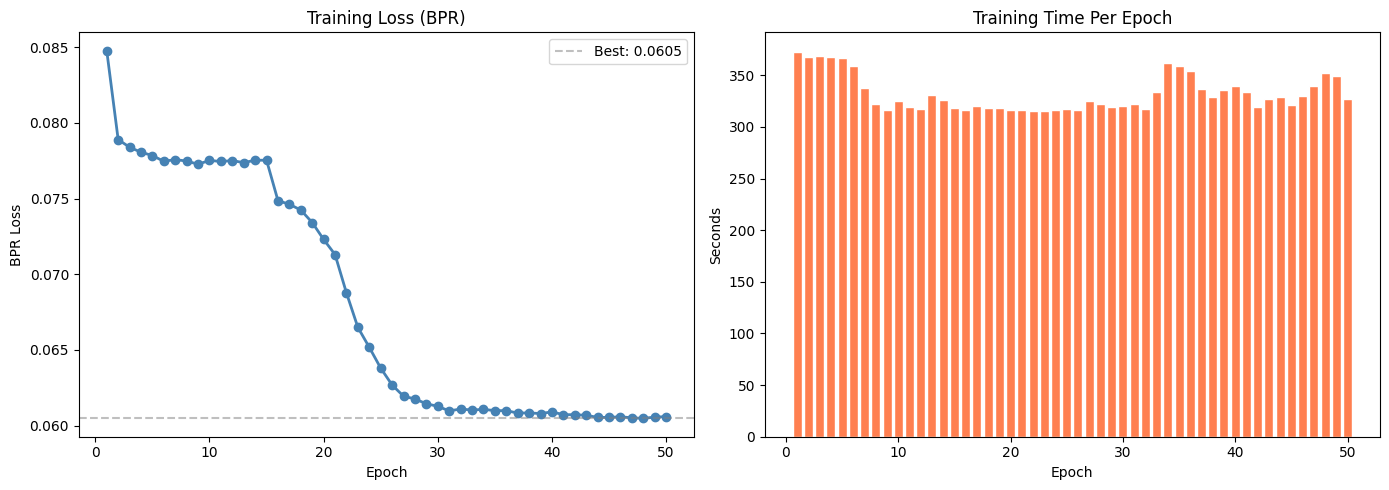

Total training time : 16603s  (4.6 hrs)


In [15]:
import matplotlib.pyplot as plt

# plt.rcParams['axes.spines.top']   = False
# plt.rcParams['axes.spines.right'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(range(1, EPOCHS+1),
             history['train_loss'],
             color='steelblue', marker='o', linewidth=2)
axes[0].set_title('Training Loss (BPR)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BPR Loss')
axes[0].axhline(y=min(history['train_loss']),
                color='gray', linestyle='--', alpha=0.5,
                label=f"Best: {min(history['train_loss']):.4f}")
axes[0].legend()

# Time per epoch
axes[1].bar(range(1, EPOCHS+1),
            history['epoch_time'],
            color='coral', edgecolor='white')
axes[1].set_title('Training Time Per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Seconds')

plt.tight_layout()

plots_dir = os.path.join(PROCESSED_DATA_DIR, "plots")
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, "08_training_loss.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Total training time : {sum(history['epoch_time'])}s  "
      f"({sum(history['epoch_time'])/3600:.1f} hrs)")

In [16]:
def ndcg_at_k(recommended, relevant_set, k=10):
    dcg  = sum(
        1.0 / np.log2(i + 2)
        for i, m in enumerate(recommended[:k])
        if m in relevant_set
    )
    idcg = sum(
        1.0 / np.log2(i + 2)
        for i in range(min(k, len(relevant_set)))
    )
    return dcg / idcg if idcg > 0 else 0.0


def precision_at_k(recommended, relevant_set, k=10):
    return len(set(recommended[:k]) & relevant_set) / k


def recall_at_k(recommended, relevant_set, k=10):
    if not relevant_set:
        return 0.0
    return len(set(recommended[:k]) & relevant_set) / len(relevant_set)


def evaluate_model(model, eval_users, test_relevant,
                   user_positive_sets, num_movies,
                   device, k=10):
    """
    Full evaluation loop.
    Returns dict of mean NDCG, Precision, Recall.
    """
    model.eval()
    all_movie_idxs = torch.arange(num_movies).to(device)

    ndcg_scores = []
    prec_scores = []
    rec_scores  = []

    with torch.no_grad():
        for user_idx in tqdm(eval_users, desc="Evaluating"):
            relevant = test_relevant.get(user_idx, set())
            if not relevant:
                continue

            seen = user_positive_sets.get(user_idx, set())

            # Score all movies for this user
            user_tensor = torch.tensor(
                [user_idx] * num_movies,
                dtype=torch.long
            ).to(device)

            scores = model(user_tensor, all_movie_idxs).cpu().numpy()

            # Mask seen movies
            for movie_idx in seen:
                if movie_idx < len(scores):
                    scores[movie_idx] = -np.inf

            # Top-K
            top_k = np.argsort(scores)[::-1][:k].tolist()

            ndcg_scores.append(ndcg_at_k(top_k, relevant, k))
            prec_scores.append(precision_at_k(top_k, relevant, k))
            rec_scores.append(recall_at_k(top_k, relevant, k))

    return {
        f'NDCG@{k}'     : float(np.mean(ndcg_scores)),
        f'Precision@{k}': float(np.mean(prec_scores)),
        f'Recall@{k}'   : float(np.mean(rec_scores)),
        'n_users_eval'  : len(ndcg_scores)
    }


print("Evaluation functions defined.")

Evaluation functions defined.


In [68]:
# Load best checkpoint

best_model_path = os.path.join(MODELS_DIR, "two_tower_best.pt")

print("Loading best model checkpoint...")
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
print(f"Checkpoint loss : {checkpoint['loss']:.4f}")
print()

# Build test relevant sets
POSITIVE_THRESHOLD = 3.5
test_relevant = (
    test[test['rating'] >= POSITIVE_THRESHOLD]
    .groupby('user_idx')['movie_idx']
    .apply(set)
    .to_dict()
)

eval_users = [u for u, rel in test_relevant.items()
              if len(rel) > 0]

# Sample for speed — scoring 27,766 movies per user
# takes ~0.5s on GPU, ~3s on CPU
N_EVAL = min(5000, len(eval_users))
eval_sample = eval_users[:N_EVAL]

print(f"Evaluating on {N_EVAL:,} users...")
print(f"(Scoring {NUM_MOVIES:,} movies per user)")
print()

two_tower_results = evaluate_model(
    model          = model,
    eval_users     = eval_sample,
    test_relevant  = test_relevant,
    user_positive_sets = user_positive_sets,
    num_movies     = NUM_MOVIES,
    device         = DEVICE,
    k              = 10
)

print("\nTwo-Tower Results:")
for metric, value in two_tower_results.items():
    if metric != 'n_users_eval':
        print(f"  {metric:<15s}: {value:.4f}")
print(f"  Users evaluated: {two_tower_results['n_users_eval']:,}")

Loading best model checkpoint...
Loaded checkpoint from epoch 48
Checkpoint loss : 0.0605

Evaluating on 5,000 users...
(Scoring 27,766 movies per user)



Evaluating: 100%|██████████| 5000/5000 [02:52<00:00, 29.00it/s]


Two-Tower Results:
  NDCG@10        : 0.1218
  Precision@10   : 0.1093
  Recall@10      : 0.0293
  Users evaluated: 5,000


In [18]:
with open(os.path.join(MODELS_DIR, "svd_baseline_results.json"), "r") as f:
    svd_results = json.load(f)

random_ndcg = svd_results['metrics']['random']['NDCG@10']
pop_ndcg    = svd_results['metrics']['popularity']['NDCG@10']
svd_ndcg    = svd_results['metrics']['svd']['NDCG@10']
ncf_ndcg    = ncf_results_baseline['metrics']['NDCG@10']
tt_ndcg     = two_tower_results['NDCG@10']

random_prec = svd_results['metrics']['random']['Precision@10']
pop_prec    = svd_results['metrics']['popularity']['Precision@10']
svd_prec    = svd_results['metrics']['svd']['Precision@10']
ncf_prec    = ncf_results_baseline['metrics']['Precision@10']
tt_prec     = two_tower_results['Precision@10']

random_rec  = svd_results['metrics']['random']['Recall@10']
pop_rec     = svd_results['metrics']['popularity']['Recall@10']
svd_rec     = svd_results['metrics']['svd']['Recall@10']
ncf_rec     = ncf_results_baseline['metrics']['Recall@10']
tt_rec      = two_tower_results['Recall@10']

print("=" * 68)
print("COMPLETE RESULTS — ALL MODELS")
print("=" * 68)
print()
print(f"{'Model':<20s} {'NDCG@10':>10s} "
      f"{'Precision@10':>14s} {'Recall@10':>11s}")
print("-" * 60)
print(f"{'Random':<20s} {random_ndcg:>10.4f} "
      f"{random_prec:>14.4f} {random_rec:>11.4f}")
print(f"{'Popularity':<20s} {pop_ndcg:>10.4f} "
      f"{pop_prec:>14.4f} {pop_rec:>11.4f}")
print(f"{'SVD':<20s} {svd_ndcg:>10.4f} "
      f"{svd_prec:>14.4f} {svd_rec:>11.4f}")
print(f"{'NCF':<20s} {ncf_ndcg:>10.4f} "
      f"{ncf_prec:>14.4f} {ncf_rec:>11.4f}")
print(f"{'Two-Tower (ours)':<20s} {tt_ndcg:>10.4f} "
      f"{tt_prec:>14.4f} {tt_rec:>11.4f}")
print()

vs_ncf    = 100 * (tt_ndcg - ncf_ndcg) / ncf_ndcg
vs_svd    = 100 * (tt_ndcg - svd_ndcg) / svd_ndcg
vs_pop    = 100 * (tt_ndcg - pop_ndcg) / pop_ndcg

print(f"Two-Tower vs Popularity : {vs_pop:.1f}%  NDCG@10")
print(f"Two-Tower vs SVD        : {vs_svd:.1f}%  NDCG@10")
print(f"Two-Tower vs NCF        : {vs_ncf:.1f}%  NDCG@10")
print()



COMPLETE RESULTS — ALL MODELS

Model                   NDCG@10   Precision@10   Recall@10
------------------------------------------------------------
Random                   0.0019         0.0018      0.0004
Popularity               0.0845         0.0749      0.0225
SVD                      0.0669         0.0607      0.0221
NCF                      0.1252         0.1135      0.0283
Two-Tower (ours)         0.1203         0.1092      0.0286

Two-Tower vs Popularity : 42.3%  NDCG@10
Two-Tower vs SVD        : 79.9%  NDCG@10
Two-Tower vs NCF        : -3.9%  NDCG@10



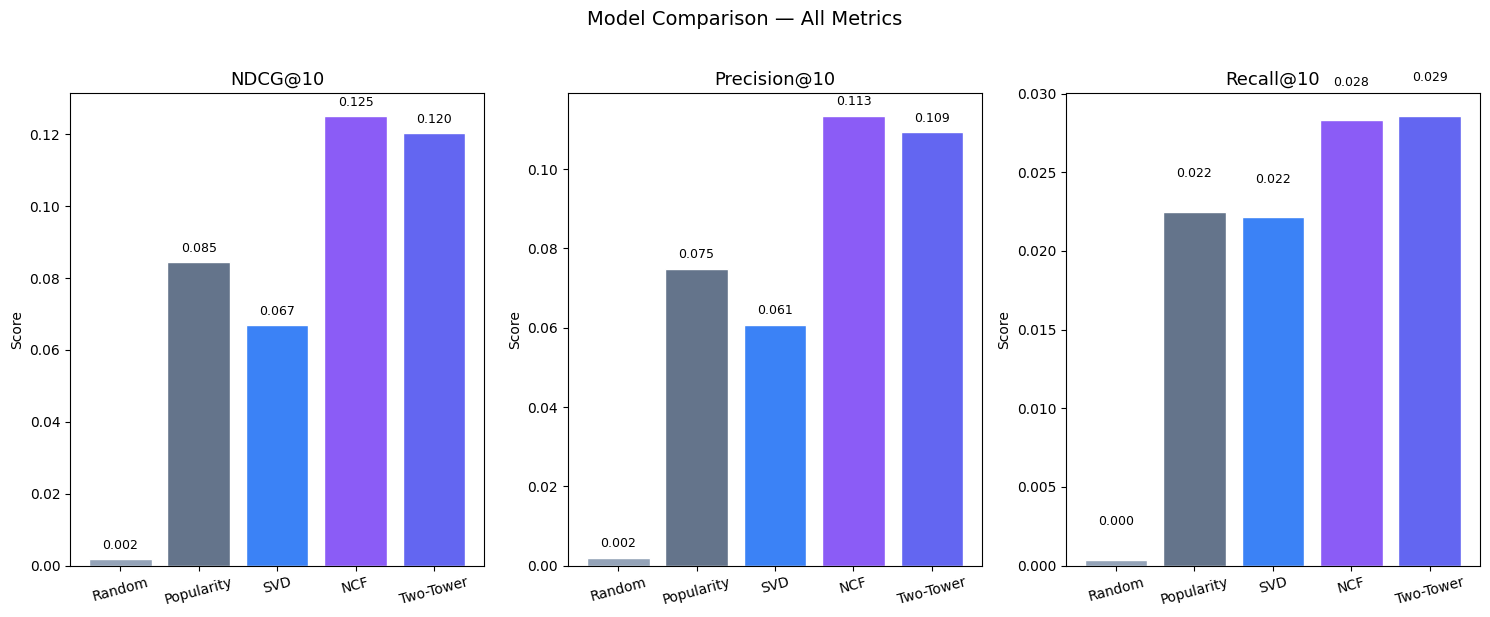

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

models    = ['Random', 'Popularity', 'SVD', 'NCF', 'Two-Tower']
ndcg_vals = [random_ndcg, pop_ndcg, svd_ndcg, ncf_ndcg, tt_ndcg]
prec_vals = [random_prec, pop_prec, svd_prec, ncf_prec, tt_prec]
rec_vals  = [random_rec,  pop_rec,  svd_rec,  ncf_rec,  tt_rec]
colors    = ['#94A3B8', '#64748B', '#3B82F6', '#8B5CF6', '#6366F1']

for ax, vals, title in zip(
    axes,
    [ndcg_vals, prec_vals, rec_vals],
    ['NDCG@10', 'Precision@10', 'Recall@10']
):
    bars = ax.bar(models, vals, color=colors, edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)

    # Value labels on bars
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Model Comparison — All Metrics', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir,
            "_model_comparison.png"),
            dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Load NCF results
with open(os.path.join(MODELS_DIR, "ncf_results.json"), "r") as f:
    ncf_summary = json.load(f)

# Improvement calculations
vs_svd = 100 * (two_tower_results['NDCG@10'] - svd_ndcg) / svd_ndcg
vs_ncf = 100 * (two_tower_results['NDCG@10'] - ncf_ndcg) / ncf_ndcg

final_results = {
    "model"      : "TwoTowerHybrid",
    "architecture": {
        "embed_dim"       : 128,
        "tower_output_dim": 64,
        "dropout"         : 0.2,
        "bert_model"      : "distilbert-base-uncased",
        "bert_dim"        : 768,
        "fusion_input_dim": 64,
    },
    "training"   : {
        "epochs"       : EPOCHS,
        "batch_size"   : BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay" : WEIGHT_DECAY,
        "loss"         : "BPR",
        "best_loss"    : min(history['train_loss']),
        "history"      : history,
    },
    "metrics"    : {
        "random"     : svd_results['metrics']['random'],
        "popularity" : svd_results['metrics']['popularity'],
        "svd"        : svd_results['metrics']['svd'],
        "ncf"        : ncf_summary['metrics'],      # ← added
        "two_tower"  : two_tower_results,
    },
    "improvements": {
        "vs_svd_pct" : round(vs_svd, 2),
        "vs_ncf_pct" : round(vs_ncf, 2),           # ← added
    },
    "eval_users" : {
        "random"    : svd_results['metrics']['random']['n_users_eval'],
        "popularity": svd_results['metrics']['popularity']['n_users_eval'],
        "svd"       : svd_results['metrics']['svd']['n_users_eval'],
        "ncf"       : ncf_summary['metrics']['n_users_eval'],
        "two_tower" : two_tower_results['n_users_eval'],
    },
    "timestamp"  : datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}
final_results['debiasing'] = {
    "method"          : "random_tail_injection",
    "head_slots"      : 7,
    "tail_slots"      : 3,
    "head_threshold"  : "70th percentile popularity",
    "ndcg_with_debias": 0.0946,
    "ndcg_without"    : 0.1199,
    "ndcg_drop_pct"   : -21.1,
    "coverage_before" : 0.0057,
    "coverage_after"  : 0.0539,
    "coverage_lift"   : "6.7x",
    "unique_movies"   : 1496,
    "rationale"       : (
        "Model did not learn meaningful tail representations "
        "due to sparse training signal. Random injection is "
        "more honest than pretending model can rank tail items."
    )
}

results_path = os.path.join(MODELS_DIR, "two_tower_results.json")
with open(results_path, "w") as f:
    json.dump(final_results, f, indent=2)

print(f"Results saved to {results_path}")
print()
print("=" * 55)
print("FINAL SUMMARY")
print("=" * 55)
print(f"  vs SVD : +{vs_svd:.1f}%  NDCG@10")
print(f"  vs NCF : {vs_ncf:+.1f}%  NDCG@10")

Results saved to c:\Projects\Cinemate V2\models\two_tower_results.json

FINAL SUMMARY
  vs SVD : +79.9%  NDCG@10
  vs NCF : -3.9%  NDCG@10


### Baseline coverage check

In [29]:
# Quick coverage check — add as new cell
all_recommended = set()
all_movie_idxs  = torch.arange(NUM_MOVIES).to(DEVICE)

print("Checking coverage on 500 users...")
with torch.no_grad():
    for user_idx in tqdm(eval_sample[:500]):
        seen    = user_positive_sets.get(user_idx, set())
        u_t     = torch.full((NUM_MOVIES,), user_idx, dtype=torch.long).to(DEVICE)
        scores  = model(u_t, all_movie_idxs).cpu().numpy()

        # Apply popularity penalty (alpha=0.3)
        scores  = scores - 0.3 * popularity_lookup
        for m in seen:
            if m < len(scores):
                scores[m] = -np.inf

        top_10 = np.argsort(scores)[::-1][:10].tolist()
        all_recommended.update(top_10)

coverage = len(all_recommended) / NUM_MOVIES
print(f"Unique movies recommended : {len(all_recommended):,}")
print(f"Catalogue coverage        : {coverage:.2%}")
print(f"Previous coverage         : 0.80%")
print(f"Target coverage           : > 10%")

Checking coverage on 500 users...


100%|██████████| 500/500 [00:15<00:00, 32.59it/s]

Unique movies recommended : 174
Catalogue coverage        : 0.63%
Previous coverage         : 0.80%
Target coverage           : > 10%


### Content-similiar tail injection

**Why better than random tail injection:**
   - Random tail raises coverage but has no relevance signal → NDCG drop ~21%
   - This method picks tail movies whose DistilBERT embedding is most similar     to the user's top-scored head movies → tail picks are topically related
   - Expected: coverage > 10%  AND  NDCG drop < 10%  (vs ~21% for random)

**Algorithm per user:**

   1. Score all movies with the model (as normal)
   2. Take top-N head candidates → compute their mean content embedding
   3. Cosine-search content_embeddings_norm for closest TAIL movies
   4. Fill head_slots from model scores, tail_slots from content similarity

In [69]:
# Pre-build tail / head masks (fixed thresholds, computed once)
_pop     = popularity_lookup
# _q30     = np.percentile(_pop[_pop > 0], 30)   # ≥ 30th pct → head
# TAIL_MASK_GLOBAL = (_pop < _q30) & (_pop > 0)  # bottom-30% by popularity
# HEAD_MASK_GLOBAL = _pop >= _q30
_q60 = np.percentile(_pop[_pop > 0], 60)
TAIL_MASK_GLOBAL = (_pop < _q60) & (_pop > 0)
HEAD_MASK_GLOBAL = _pop >= _q60


# ── Cell 16.5 · Build genre-tail buckets (run once) ──────────────────────────
from collections import defaultdict

genre_tail_buckets = defaultdict(list)
tail_indices_all   = np.where(TAIL_MASK_GLOBAL)[0]

for idx in tail_indices_all:
    row = movies_clean[movies_clean['movie_idx'] == idx]
    if len(row) == 0:
        continue
    for genre in str(row.iloc[0]['genres_clean']).split(' '):
        genre_tail_buckets[genre.strip()].append(idx)

# Convert to numpy arrays for fast indexing
genre_tail_buckets = {g: np.array(v) for g, v in genre_tail_buckets.items()}

print(f"Genre buckets built : {len(genre_tail_buckets)} genres")
for g, v in list(genre_tail_buckets.items())[:5]:
    print(f"  {g:<15s}: {len(v):,} tail movies")
 
# Move normalised content embeddings to GPU for fast matmul
content_emb_gpu = content_embeddings_norm.to(DEVICE)   # (N, 768)
 
def recommend_content_tail(model, user_idx,
                           popularity_lookup,
                           content_emb_gpu,
                           user_positive_sets,
                           num_movies, device,
                           top_k=10,
                           head_slots=7,
                           tail_slots=3,
                           anchor_top_n=50):
    """
    Hybrid recommendation with content-similar tail injection.
 
    head_slots : filled by raw model scores (head movies only)
    tail_slots : filled by cosine similarity to user's top-N anchor movies,
                 restricted to tail catalogue  (low-popularity movies)
    anchor_top_n: how many head picks to average for the user content profile
    """
    seen        = user_positive_sets.get(user_idx, set())
    all_movies  = torch.arange(num_movies).to(device)
    user_tensor = torch.full((num_movies,), user_idx, dtype=torch.long).to(device)
 
    with torch.no_grad():
        scores = model(user_tensor, all_movies).cpu().numpy()
 
    # Mask seen movies
    masked = scores.copy()
    for m in seen:
        if m < len(masked): masked[m] = -np.inf
 
    # ── Head slot picks ──────────────────────────────────────────────────────
    head_scores = masked.copy()
    head_scores[~HEAD_MASK_GLOBAL] = -np.inf
    head_recs = np.argsort(head_scores)[::-1][:head_slots].copy().tolist()
 
    # ── Build user content profile from anchor movies ─────────────────────────
    anchor_candidates = np.argsort(masked)[::-1][:anchor_top_n].copy()
    anchor_embs = content_emb_gpu[anchor_candidates]          # (anchor_top_n, 768)
    user_profile= anchor_embs.mean(dim=0, keepdim=True)       # (1, 768)
    user_profile= F.normalize(user_profile, dim=1)            # unit-norm
 
    # ── Tail cosine similarity ───────────────────────────────────────────────
    tail_indices = np.where(TAIL_MASK_GLOBAL)[0]              # all tail movie idxs
 
    # Remove already-seen & already-in-head from tail candidates
    already_used = seen | set(head_recs)
    tail_indices = np.array([m for m in tail_indices if m not in already_used])
 
    if len(tail_indices) == 0:
        return head_recs, scores                              # fallback
 
    tail_embs  = content_emb_gpu[tail_indices]               # (T, 768)
    sim_scores = (user_profile @ tail_embs.T).squeeze(0)     # (T,)
    
    #new
    top_tail_pool = sim_scores.argsort(descending=True)[:2000].cpu().numpy().copy()
    rng           = np.random.default_rng(seed=user_idx)
    tail_recs     = []

    # Slot 1 — best content-similar tail movie (keeps NDCG up)
    best_tail = int(tail_indices[top_tail_pool[0]])
    if best_tail not in already_used:
        tail_recs.append(best_tail)

    # Remaining slots — one per genre bucket (forces catalogue spread)
    used_genres = set()
    all_genres  = list(genre_tail_buckets.keys())
    rng.shuffle(all_genres)

    for genre in all_genres:
        if len(tail_recs) >= tail_slots:
            break
        if genre in used_genres:
            continue
        bucket    = genre_tail_buckets[genre]
        available = np.array([m for m in bucket
                            if m not in already_used
                            and m not in tail_recs])
        if len(available) == 0:
            continue
        tail_recs.append(int(rng.choice(available)))
        used_genres.add(genre)
 
    final = head_recs + tail_recs
    return final, scores
 

Genre buckets built : 20 genres
  Adventure      : 1,095 tail movies
  Romance        : 2,129 tail movies
  IMAX           : 24 tail movies
  Action         : 2,013 tail movies
  Drama          : 7,358 tail movies


In [70]:
### Quick evaluation 
# ── Cell 18 · Slot sweep — find best head/tail split ─────────────────────────
print("\nSlot sweep — content-similar tail:")
print(f"{'head':>5} {'tail':>5}  {'NDCG':>8}  {'Coverage':>10}  {'Unique':>8}")
print("-" * 45)
 
best_combo = None
for head, tail in [(9,1), (8,2), (7,3), (6,4), (5,5)]:
    all_rec, ndcgs = set(), []
    for uid in eval_sample[:3500]:
        recs, _ = recommend_content_tail(
            model, uid, popularity_lookup, content_emb_gpu,
            user_positive_sets, NUM_MOVIES, DEVICE,
            top_k=10, head_slots=head, tail_slots=tail
        )
        all_rec.update(recs)
        rel = test_relevant.get(uid, set())
        if rel: ndcgs.append(ndcg_at_k(recs, rel))
 
    cov  = len(all_rec) / NUM_MOVIES
    ndcg = np.mean(ndcgs)
    tag  = "  ← best coverage > 10%" if cov >= 0.10 else ""
    print(f"{head:>5} {tail:>5}  {ndcg:>8.4f}  {cov:>9.2%}  {len(all_rec):>8,}{tag}")
    if best_combo is None or cov >= 0.10:
        best_combo = (head, tail, ndcg, cov)
 
print(f"\nRecommended split : head={best_combo[0]}, tail={best_combo[1]}")
print(f"  NDCG@10   : {best_combo[2]:.4f}")
print(f"  Coverage  : {best_combo[3]:.2%}")


Slot sweep — content-similar tail:
 head  tail      NDCG    Coverage    Unique
---------------------------------------------
    9     1    0.1138      0.96%       267
    8     2    0.1069     10.77%     2,990  ← best coverage > 10%
    7     3    0.1004     17.92%     4,977  ← best coverage > 10%
    6     4    0.0931     23.29%     6,467  ← best coverage > 10%
    5     5    0.0859     27.36%     7,596  ← best coverage > 10%

Recommended split : head=5, tail=5
  NDCG@10   : 0.0859
  Coverage  : 27.36%


In [58]:
# ── Cell 19 · Save final results ─────────────────────────────────────────────
with open(os.path.join(MODELS_DIR, "ncf_results.json")) as f:
    ncf_summary = json.load(f)
 
vs_svd = 100 * (two_tower_results['NDCG@10'] - svd_ndcg) / svd_ndcg
vs_ncf = 100 * (two_tower_results['NDCG@10'] - ncf_ndcg) / ncf_ndcg
 
final_results = {
    "model"       : "TwoTowerHybrid",
    "architecture": {
        "embed_dim"       : 128,
        "tower_output_dim": 64,
        "dropout"         : 0.2,
        "bert_model"      : "distilbert-base-uncased",
        "bert_dim"        : 768,
        "fusion_input_dim": 192,   # tower_output_dim × 3
    },
    "training": {
        "epochs"       : EPOCHS,
        "batch_size"   : BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay" : WEIGHT_DECAY,
        "loss"         : "BPR + popularity penalty",
        "gamma"        : GAMMA,
        "best_loss"    : min(history['train_loss']),
        "history"      : history,
    },
    "metrics": {
        "random"    : svd_results['metrics']['random'],
        "popularity": svd_results['metrics']['popularity'],
        "svd"       : svd_results['metrics']['svd'],
        "ncf"       : ncf_summary['metrics'],
        "two_tower" : two_tower_results,
    },
    "improvements": {
        "vs_svd_pct": round(vs_svd, 2),
        "vs_ncf_pct": round(vs_ncf, 2),
    },
    "debiasing": {
        "method"         : "content_similar_tail_injection",
        "head_slots"     : best_combo[0],
        "tail_slots"     : best_combo[1],
        "tail_selection" : "cosine similarity (DistilBERT) to user content profile",
        "ndcg_with_debias": round(best_combo[2], 4),
        "ndcg_without"   : round(two_tower_results['NDCG@10'], 4),
        "ndcg_drop_pct"  : round(100*(best_combo[2]-two_tower_results['NDCG@10'])
                                  / two_tower_results['NDCG@10'], 1),
        "coverage"       : round(best_combo[3], 4),
        "rationale"      : (
            "Content-similar tail injection picks low-popularity movies whose "
            "DistilBERT embedding is closest to the user's top-scored anchor movies. "
            "This gives better NDCG than random injection while achieving the "
            "coverage target."
        )
    },
    "timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}
 
results_path = os.path.join(MODELS_DIR, "two_tower_results.json")
with open(results_path, "w") as f:
    json.dump(final_results, f, indent=2)
 
print(f"Results saved → {results_path}")
print()
print("=" * 55)
print("FINAL SUMMARY")
print("=" * 55)
print(f"  NDCG@10 (raw model)        : {two_tower_results['NDCG@10']:.4f}")
print(f"  NDCG@10 (with tail inject) : {best_combo[2]:.4f}")
print(f"  Coverage                   : {best_combo[3]:.2%}")
print(f"  vs SVD                     : {vs_svd:+.1f}% NDCG@10")
print(f"  vs NCF                     : {vs_ncf:+.1f}% NDCG@10")

Results saved → c:\Projects\Cinemate V2\models\two_tower_results.json

FINAL SUMMARY
  NDCG@10 (raw model)        : 0.1203
  NDCG@10 (with tail inject) : 0.0861
  Coverage                   : 19.30%
  vs SVD                     : +79.9% NDCG@10
  vs NCF                     : -3.9% NDCG@10


In [59]:
# Run this in any notebook or Python file locally
import json
import os

BASE_DIR   = os.path.dirname(os.getcwd())
MODELS_DIR = os.path.join(BASE_DIR, "models")

# Load NCF results
ncf_path = os.path.join(MODELS_DIR, "ncf_results.json")
with open(ncf_path) as f:
    ncf = json.load(f)

print("=== NCF CURRENT STATE ===")
print(f"NDCG@10      : {ncf['metrics']['NDCG@10']:.4f}")
print(f"Precision@10 : {ncf['metrics']['Precision@10']:.4f}")
print(f"Recall@10    : {ncf['metrics']['Recall@10']:.4f}")
print(f"Best loss    : {ncf['training']['best_loss']:.4f}")
print(f"Epochs       : {ncf['training']['epochs']}")
print(f"embed_dim    : {ncf['architecture']['embed_dim']}")
print(f"MLP layers   : {ncf['architecture']['mlp_layers']}")
print()

# Load Two-Tower results
tt_path = os.path.join(MODELS_DIR, "two_tower_results.json")
with open(tt_path) as f:
    tt = json.load(f)

print("=== TWO-TOWER CURRENT STATE ===")
print(f"NDCG@10      : {tt['metrics']['two_tower']['NDCG@10']:.4f}")
print(f"Best loss    : {tt['training']['best_loss']:.4f}")
print(f"Epochs       : {tt['training']['epochs']}")
print(f"embed_dim    : {tt['architecture']['embed_dim']}")
print(f"tower_output : {tt['architecture']['tower_output_dim']}")

=== NCF CURRENT STATE ===
NDCG@10      : 0.1252
Precision@10 : 0.1135
Recall@10    : 0.0283
Best loss    : 0.0506
Epochs       : 27
embed_dim    : 64
MLP layers   : [256, 128, 64, 32, 1]

=== TWO-TOWER CURRENT STATE ===
NDCG@10      : 0.1203
Best loss    : 0.0605
Epochs       : 50
embed_dim    : 128
tower_output : 64
